In [1]:
#imports
import sys
sys.path.append("../../src")
# A collection of handy imports. Not that important.
from common_imports import * 
import numerical_quenches as nq
from numerical_quenches import g_linear_hold

#These imports will be used to calculate projectors
import kibble_zurek as kz
import time_evolved_z_correlators as zz



In [147]:
#Define Sudden quench protocol
def g_sudden_quench(t,args):
    g0,gf,t0 = args
    if t<t0:
        return g0
    else:
        return gf

#Critical Times of DQPTs
def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns
def est_z_defects(tau,n):
    numerator = n*n+n
    denom = 2**(n-1)*4*pi*sqrt(2*tau)
    return numerator/denom

def est_x_defects(tau,n):
    denom = 4*pi*sqrt(2*tau)

    return (n-1)/denom

critical_times(0,10)

array([ 0.78539816,  2.35619449,  3.92699082,  5.49778714,  7.06858347,
        8.6393798 , 10.21017612, 11.78097245, 13.35176878, 14.9225651 ])

In [256]:
tau = 5
L = 100
#Time Evaluation interval
t_eval = np.linspace(-tau, tau, 100,endpoint=False)
print(t_eval)
t_eval = np.concatenate((t_eval,np.linspace(tau,tau+2*t0,25)))
#This variable lets us always say that t_plot=0 is when to compare them
t_plot = t_eval-tau
#Arguments for Quench Protocols
slow_args = [tau,tau]
g0 = g_linear_hold(t_eval[0],slow_args)
gf = g_linear_hold(tau,slow_args)
sudden_args=[g0,gf,tau]

[-5.  -4.9 -4.8 -4.7 -4.6 -4.5 -4.4 -4.3 -4.2 -4.1 -4.  -3.9 -3.8 -3.7
 -3.6 -3.5 -3.4 -3.3 -3.2 -3.1 -3.  -2.9 -2.8 -2.7 -2.6 -2.5 -2.4 -2.3
 -2.2 -2.1 -2.  -1.9 -1.8 -1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9
 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5
  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9
  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8  2.9  3.   3.1  3.2  3.3
  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1  4.2  4.3  4.4  4.5  4.6  4.7
  4.8  4.9]


Text(0, 0.5, '$g(t)$')

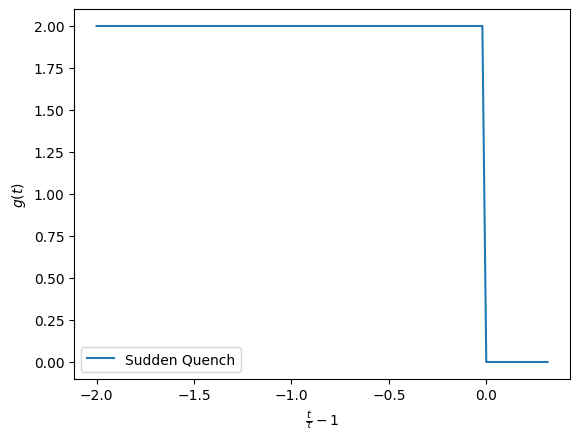

In [257]:
#plot(t_plot/tau, [g_linear_hold(ti,slow_args) for ti in t_plot],label="Slow Quench")
plot(t_plot/tau, [g_sudden_quench(ti,sudden_args) for ti in t_eval],label="Sudden Quench")
legend()
xlabel(r"$\frac{t}{\tau}-1$")
ylabel(r"$g(t)$")

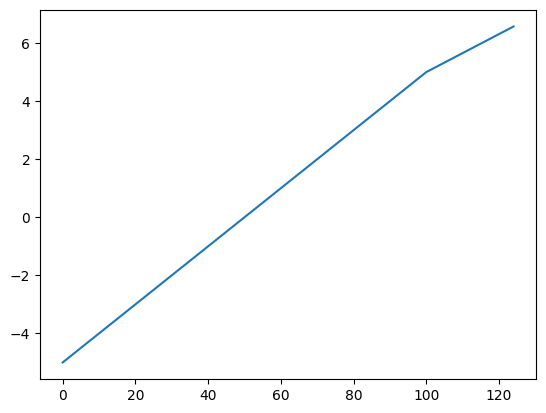

In [258]:
plot(t_eval)

In [259]:
slow_states = nq.states(L,t_eval,g_linear_hold,slow_args)
sudden_states = nq.states(L,t_eval,g_sudden_quench,sudden_args)
tns = critical_times(gf,10)


2.0
2.0


In [ ]:
 P1 = array([[zz.P_n(ni, s)
             for s, t in zip(slow_states, t_eval) if t > tau]
            for ni in ns])
P2 = array([[zz.P_n(ni, s)
             for s, t in zip(sudden_states, t_eval) if t > tau]
            for ni in ns])


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Numerical Quenches/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


Text(0.5, 0, "$t'=t/\\tau-1$")

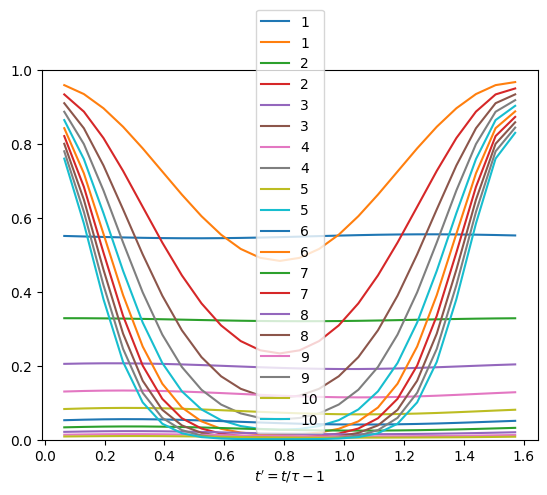

In [262]:
predicted_defects = []
KZ_defects = []
sudden_defects = []
t0_defects = []

for p1,p2,ni in zip(P1,P2,ns):
    est_defect = est_z_defects(tau,ni)

    #Time Averages over t_plot>0
    KZ_avg = abs(np.average(p1))
    sudden_avg = abs(np.average(p2))
    #T=0 value:
    Pn_t0 = abs(p1[0])
    ##Defects##
    KZ_defect_n = abs(1/2**ni - KZ_avg)
    sudden_defect_n = abs(1/2**ni-sudden_avg)
    t0_defect_n = abs(1/2**ni-Pn_t0)

    #Appending
    predicted_defects.append(est_defect)
    KZ_defects.append(KZ_defect_n)
    sudden_defects.append(sudden_defect_n)
    t0_defects.append(t0_defect_n)

    plot(t_plot[t_plot>0],p1,label=ni)
    plot(t_plot[t_plot>0],p2,label=ni)

    #plot(-log(p2)/ni)
#plt.vlines(critical_times(0,10)/tau,0,1,color="black",ls="--")
ylim(0,1)
#xlim(0,t_plot[-1]/tau)
legend()
predicted_defects = array(predicted_defects)
KZ_defects = array(KZ_defects)
sudden_defects = array(sudden_defects)
t0_defects = array(t0_defects)
xlabel(r"$t'=t/\tau-1$")

Text(0, 0.5, '$\\delta$')

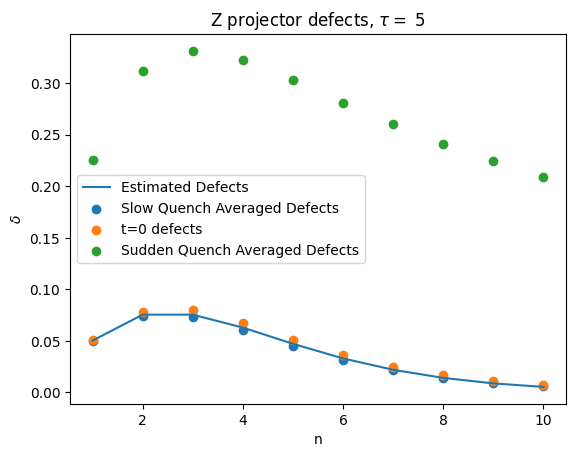

In [263]:
plot(ns,predicted_defects,label="Estimated Defects")
scatter(ns,KZ_defects,label="Slow Quench Averaged Defects")
scatter(ns,t0_defects,label="t=0 defects")
scatter(ns,sudden_defects,label="Sudden Quench Averaged Defects")
legend()
title(rf"Z projector defects, $\tau= $ {tau}")
xlabel("n")
ylabel(r"$\delta$")


In [275]:
ns = [2,3,4,5,6,7,8,9,10,11,12]
P1 = array([[kz.P_n(ni, s)
             for s, t in zip(slow_states, t_eval) if t > tau]
            for ni in ns])
P2 = array([[kz.P_n(ni, s)
             for s, t in zip(sudden_states, t_eval) if t > tau]
            for ni in ns])


Text(0.5, 0, "$t'=t/\\tau-1$")

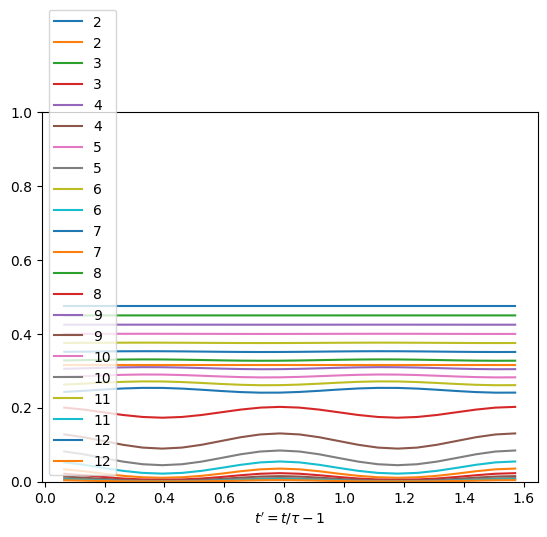

In [276]:
predicted_defects = []
KZ_defects = []
sudden_defects = []
t0_defects = []

for p1,p2,ni in zip(P1,P2,ns):
    est_defect = est_x_defects(tau,ni)

    #Time Averages over t_plot>0
    KZ_avg = abs(np.average(p1))
    sudden_avg = abs(np.average(p2))
    #T=0 value:
    Pn_t0 = abs(p1[0])
    ##Defects##
    KZ_defect_n = abs(1/2 - KZ_avg)
    sudden_defect_n = abs(1/2-sudden_avg)
    t0_defect_n = abs(1/2-Pn_t0)

    #Appending
    predicted_defects.append(est_defect)
    KZ_defects.append(KZ_defect_n)
    sudden_defects.append(sudden_defect_n)
    t0_defects.append(t0_defect_n)

    plot(t_plot[t_plot>0],p1,label=ni)
    plot(t_plot[t_plot>0],p2,label=ni)

    #plot(-log(p2)/ni)
#plt.vlines(critical_times(0,10)/tau,0,1,color="black",ls="--")
ylim(0,1)
#xlim(0,t_plot[-1]/tau)
legend()
predicted_defects = array(predicted_defects)
KZ_defects = array(KZ_defects)
sudden_defects = array(sudden_defects)
t0_defects = array(t0_defects)
xlabel(r"$t'=t/\tau-1$")

Text(0, 0.5, '$\\delta$')

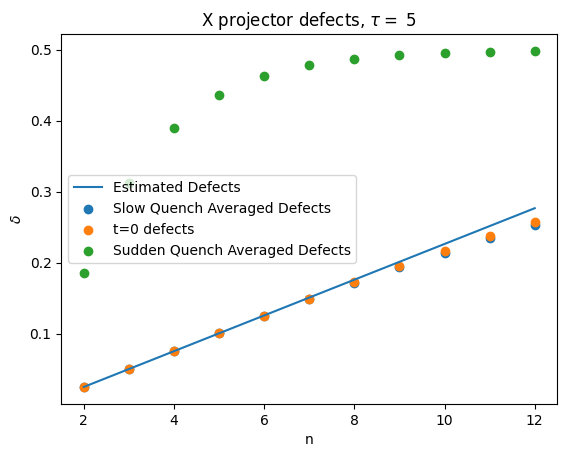

In [279]:
plot(ns,predicted_defects,label="Estimated Defects")
scatter(ns,KZ_defects,label="Slow Quench Averaged Defects")
scatter(ns,t0_defects,label="t=0 defects")
scatter(ns,sudden_defects,label="Sudden Quench Averaged Defects")
legend()
title(rf"X projector defects, $\tau= $ {tau}")
xlabel("n")
ylabel(r"$\delta$")


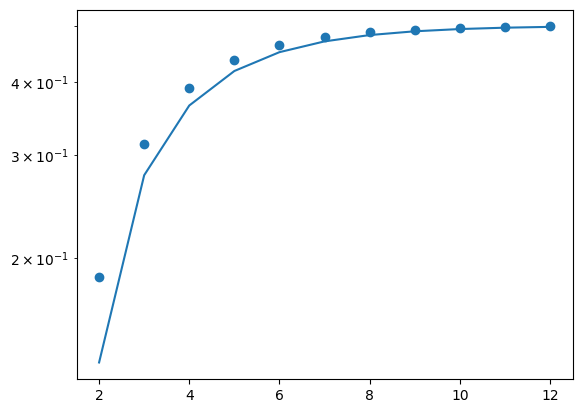

In [305]:
scatter(ns,sudden_defects,label="Sudden Quench Averaged Defects")
yscale("log")
ns=array(ns)
plot(ns,1/2-exp(-ns/2))